# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty to Mean Squared Error prevents a model from overfitting to noise in the training data. By penalizing large parameter values, the model becomes less sensitive to small fluctuations. This results in a smoother and more stable prediction function. This approach applies the bias-variance tradeoff and accepts a slightly higher training error to ensure the model generalizes better to new, unseen data.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization manages model complexity by adjusting the penalty hyperparameter. This dictates the priority given to minimizing error versus keeping parameters small. Increasing this penalty introduces bias because the model is prevented from fitting the training data perfectly. However, this intentional bias reduces variance by making the model less sensitive to random noise and training-set fluctuations.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

The main difference is that LASSO can force coefficients to exactly zero, which creates a sparse model through automatic feature selection. Ridge regression shrinks all coefficients toward zero but keeps every feature in the final model, which provides more stability when predictors are highly correlated. LASSO answers typically consist of a simplified subset of the original variables, where Ridge answers include all variables with reduced magnitudes.

4. How do we typically scale variables for use in regularized regression? Why?

We typically scale variables using standardization, which transforms each feature to have a mean of zero and a standard deviation of one. This step is very important because regularization penalties are applied directly to the magnitude of the model's coefficients. Since coefficient sizes are inversely proportional to the scale of their corresponding features, variables with larger numerical ranges would be penalized less heavily than those with smaller ranges.

5. How is the penalty $\alpha$ typically selected?

The penalty parameter $\alpha$ is typically selected using k-fold cross-validation to identify the value that generalizes best to unseen data. A range of potential $\alpha$ values is tested by training the model on different subsets of the data and measuring the resulting average validation error for each. The value that minimizes this error is generally chosen as the optimal parameter. 

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

The penalty term is excluded because the objective is to measure a model's true predictive accuracy on unseen data. The penalty is used during training to constrain parameters, but the validation error must remain a pure measure of the distance between predictions and targets. Including the penalty in evaluation would bias the selection process toward simpler models rather than the most accurate ones.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [11]:
# Q2.1
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import matplotlib.pyplot as plt

# load in data 
df = pd.read_csv('data/cars_hw.csv')
df.head()

# Create Age
df['Age'] = 2026 - df['Make_Year'] 
X = df[['Mileage_Run', 'Age']]

# (a) Polynomial Expansion (Degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

# (b) Z-score normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)


In [12]:
# Q2.2

from sklearn.linear_model import LinearRegression, LassoCV


lr = LinearRegression().fit(X_scaled, df['Price']) 
interaction_idx = list(feature_names).index('Mileage_Run Age')
interaction_coef = lr.coef_[interaction_idx]

print(f"Interaction Coefficient: {interaction_coef}")

Interaction Coefficient: -1671212.3563918832


The sign for interaction between Mileage_Run and Age is very negative. This means that as both mileage and age increase, they have a compounding negative effect on the car's predicted price. Compounding effect means it's beyond their individual impacts.

In [18]:
# Q2.3

alphas_grid = np.logspace(1, 3, 20)

# had to increase max_iter parameter because I got convergence warnings
lasso_cv = LassoCV(alphas=alphas_grid, cv=20, max_iter=100000).fit(X_scaled, df['Price'])

print(f"Optimal Alpha: {lasso_cv.alpha_}")

Optimal Alpha: 88.58667904100822


The output identifies 88.59 as the optimal penalty strength that minimizes cross-validated MSE. This value represents the specific level of regularization needed to balance accuracy with model simplicity.

Text(0.5, 1.0, 'Cross-Validated MSE by Alpha')

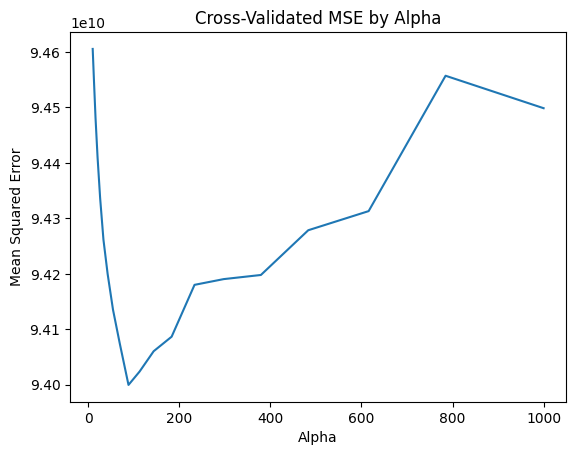

In [19]:
# Q2.4 

# Plot CV MSE
mse_path = lasso_cv.mse_path_.mean(axis=1)
plt.figure()
plt.plot(lasso_cv.alphas_, mse_path)
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Cross-Validated MSE by Alpha')

Lowest point is at 88.59!

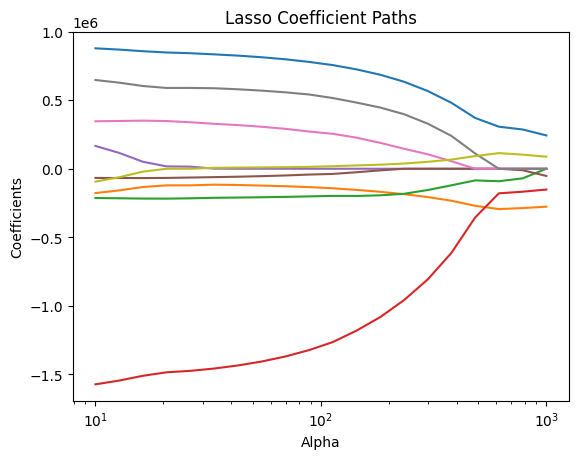

In [21]:
# Q2.5 Plot coefficient paths
from sklearn.linear_model import Lasso
coefs = []
for a in alphas_grid:
    l = Lasso(alpha=a, max_iter=100000).fit(X_scaled, df['Price'])
    coefs.append(l.coef_)

plt.figure()
plt.plot(alphas_grid, coefs)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Lasso Coefficient Paths')
plt.show()

In [24]:
# Q2.6

print(f"The Features Selected are: {feature_names[lasso_cv.coef_ != 0]}")

print(f"The Proportion set equal to Zero are: {np.mean(lasso_cv.coef_ == 0)}")


The Features Selected are: ['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Mileage_Run^3'
 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']
The Proportion set equal to Zero are: 0.1111111111111111


The Purple Line is the only one that hits zero early, so if only 1 out of 9 features is zeroed out, the proportion is 1/9 = 11.1%.

Q2.7

No coefficients increase in magnitude. Every single line trends toward zero as Alpha increases. This is the intended effect of the penalty, as it shrinks the coefficients to prevent the overfitting seen in the unregularized linear regression.

No coefficients change signs. They all stay on their original side as they approach zero, which confirms that regularization is not reversing the existing relationship, it is just diminishing it.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [28]:
# Q3.1

df = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [29]:
y = df['DEATH_EVENT']
# Continuous features: 3rd-degree expansion
X_cont = df[['age', 'ejection_fraction', 'serum_creatinine']]
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont_poly = poly_cont.fit_transform(X_cont)
X_cont_scaled = StandardScaler().fit_transform(X_cont_poly)

# Categorical features: Interactions only
X_cat = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
poly_cat = PolynomialFeatures(interaction_only=True, include_bias=False)
X_cat_interact = poly_cat.fit_transform(X_cat)

# Concatenate all features
X_full = np.hstack([X_cont_scaled, X_cat_interact])

In [30]:
# Q3.2: Run the unregularized linear regression
lr = LinearRegression().fit(X_full, y)

# Print coefficients to check for counterintuitive signs
for name, coef in zip(poly_cont.get_feature_names_out().tolist() + poly_cat.get_feature_names_out().tolist(), lr.coef_):
    print(f"{name}: {coef:.4f}")

age: 1.5392
ejection_fraction: -2.1925
serum_creatinine: -0.8536
age^2: -3.6787
age ejection_fraction: -0.6009
age serum_creatinine: 1.8416
ejection_fraction^2: 3.4310
ejection_fraction serum_creatinine: 2.6734
serum_creatinine^2: -2.6470
age^3: 1.9931
age^2 ejection_fraction: 0.9080
age^2 serum_creatinine: -0.6975
age ejection_fraction^2: -0.0812
age ejection_fraction serum_creatinine: -1.5777
age serum_creatinine^2: 1.2841
ejection_fraction^3: -1.2503
ejection_fraction^2 serum_creatinine: -1.2700
ejection_fraction serum_creatinine^2: 1.1795
serum_creatinine^3: 0.0722
anaemia: 0.0081
diabetes: -0.0707
high_blood_pressure: -0.0079
smoking: -0.1027
anaemia diabetes: 0.0262
anaemia high_blood_pressure: -0.0273
anaemia smoking: 0.0649
diabetes high_blood_pressure: 0.1324
diabetes smoking: 0.1561
high_blood_pressure smoking: 0.1015


Q3.2

Negative coefficients for risk factors like smoking and diabetes are counterintuitive because they incorrectly suggest these conditions decrease the probability of death. This occurs due to multicollinearity, where the unregularized model assigns extreme, opposing weights to redundant features to fit specific noise in the training data. The higher-order powers and interactions are intended to capture complex, non-linear relationships that a simple linear model misses, so they require a regularization penalty to stay numerically stable and provide logically sound results.

In [31]:
# Q3.3 

# Wide alpha grid
alphas_grid = np.logspace(-5, 5, 30)

# Use 20-fold CV and high max_iter to ensure convergence
lasso_cv = LassoCV(alphas=alphas_grid, cv=20, max_iter=100000).fit(X_full, y)

print(f"Optimal Alpha: {lasso_cv.alpha_}")

Optimal Alpha: 0.005736152510448681


Text(0.5, 1.0, 'CV MSE vs Alpha')

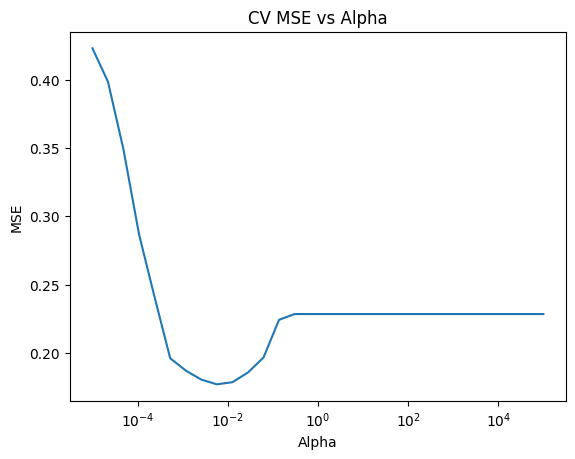

In [34]:
# Q3.4: Plot CV MSE
plt.figure()
plt.semilogx(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=1))
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('CV MSE vs Alpha')

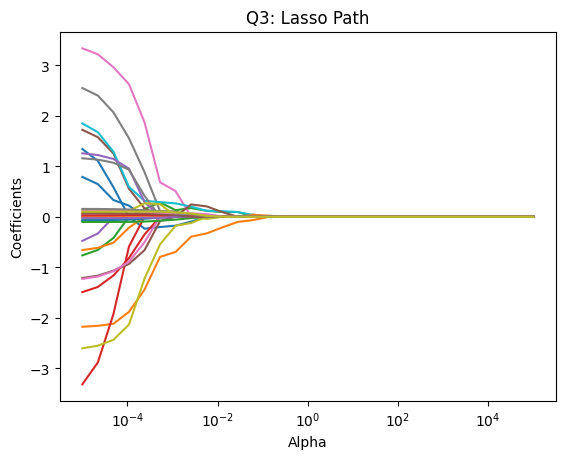

In [35]:
# Q3.5
# Plot Path
from sklearn.linear_model import Lasso
coef_path = []
for a in alphas_grid:
    l = Lasso(alpha=a, max_iter=100000).fit(X_full, y)
    coef_path.append(l.coef_)

plt.figure()
plt.semilogx(alphas_grid, coef_path)
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Q3: Lasso Path')
plt.show()

In [37]:
np.mean(lasso_cv.coef_ == 0)

np.float64(0.5862068965517241)

In [38]:
# Create names for the 19 continuous features
names_cont = poly_cont.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])

# Create names for the 10 categorical interaction features
names_cat = poly_cat.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])

# Combine them into one list of 29
feature_names_full = np.concatenate([names_cont, names_cat])

print("Selected Features:")
print(feature_names_full[lasso_cv.coef_ != 0])

# Proportion calculation
prop_zero = np.mean(lasso_cv.coef_ == 0)
print(f"\nProportion of features set to zero: {prop_zero:.2%}")

Selected Features:
['ejection_fraction' 'serum_creatinine' 'age^3' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine' 'serum_creatinine^3' 'anaemia'
 'diabetes' 'high_blood_pressure' 'diabetes high_blood_pressure'
 'diabetes smoking' 'high_blood_pressure smoking']

Proportion of features set to zero: 58.62%


Q3.6 

The optimal alpha is around 0.01, so this shows that the model selects only the most predictive features. The selected features are: ejection_fraction, serum_creatinine, age³, ejection_fraction³, ejection_fraction² serum_creatinine, serum_creatinine³, anaemia, diabetes, high_blood_pressure, diabetes high_blood_pressure, diabetes smoking, and high_blood_pressure smoking.

58.62% of the original 29 features were set to zero, which successfully removes the majority of the redundant terms that were causing model instability. 

Comparing the linear regression to the regularized model, no coefficients increased in magnitude or changed sign as alpha increased. They trended strictly toward zero. While the original unregularized regression produced counterintuitive signs for risk factors like diabetes and smoking, the LASSO model stabilizes these parameters by eliminating the multicollinearity that caused those reversals.

This difference in behavior highlights the bias-variance trade-off. The unregularized linear model suffers from high variance, fitting the specific noise and redundant correlations in the training data, which results in illogical coefficients. By introducing the penalty, LASSO adds a small amount of bias to achieve a reduction in variance. This creates a simpler, more robust model that captures true clinical signals rather than random dataset points.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

The objective function for this problem combines the MSE with the L2 penalty term specified.    $$J(\tilde{b}_0, \tilde{b}_1) = \frac{1}{n} \sum_{i=1}^{n} (\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1 \tilde{x}_i)^2 + \alpha (\tilde{b}_1)^2$$


2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

Take the partial derivative of b0 and set it to zero:

$$\frac{\partial J}{\partial \tilde{b}_0} = -\frac{2}{n} \sum_{i=1}^{n} (\tilde{y}_i - \tilde{b}_0 - \tilde{b}_1 \tilde{x}_i) = 0$$


$$\sum \tilde{y}_i - n\tilde{b}_0 - \tilde{b}_1 \sum \tilde{x}_i = 0$$



Because the data is mean-centered, the equation simplifies to $-n\tilde{b}_0 = 0$.  Therefore: b0 = 0

Partial deriv of b1 and substitute b0 = 0:

$$\frac{\partial J}{\partial \tilde{b}_1} = -\frac{2}{n} \sum_{i=1}^{n} (\tilde{y}_i - \tilde{b}_1 \tilde{x}_i)\tilde{x}_i + 2\alpha \tilde{b}_1 = 0$$

$$\frac{1}{n} \sum \tilde{x}_i \tilde{y}_i - \frac{\tilde{b}_1}{n} \sum \tilde{x}_i^2 - \alpha \tilde{b}_1 = 0$$

then solve for b1:    $$\tilde{b}_1 = \frac{\sum \tilde{x}_i \tilde{y}_i}{\sum \tilde{x}_i^2 + n\alpha}$$




3. How does increasing $\alpha$ change the slope coefficient?

As alpha increases, the value in the denominator of the slope equation increases. Since the numerator remains constant, the magnitude of the slope coefficient b1 is shrunk toward zero. In the limit as alpha goes to infinity, the slope becomes exactly zero, and the model just predicts the mean of y.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

The challenge is that the absolute value function is not differentiable at zero. We cannot solve for b1 by setting a single derivative to zero across all values. We have to use subgradient calculus. In LASSO, the coefficient is set exactly to zero if the predictive strength of the variable is less than the penalty cost. If the correlation between x and y is too weak to overcome the threshold set by alpha, LASSO performs automatic feature selection and removes the variable from the model entirely.


I did Q4.2 on paper and then had an AI convert the symbols over for the markdown cell to look nicer.